# Понять, почему часть заказов получает 1-2 звезды, и на какие зоны риска бизнесу смотреть в первую очередь.

## Рабочие гипотезы
- `H1`: просрочка доставки повышает риск плохого отзыва.
- `H2`: чем дольше доставка, тем ниже оценка.
- `H3`: есть группа продавцов, которая дает непропорционально много late+bad заказов.

Дальше иду по шагам: сначала качество данных, потом витрины, затем метрики, графики, проверка гипотез и выводы для команды.

## 1) Поднимаем SQL-базу.

In [1]:
import duckdb
import pandas as pd

my_con = duckdb.connect(":memory:")

table_names = ["orders", "order_items", "payments", "reviews", "customers"]
csv_files = [
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_customers_dataset.csv",
]

for table_name, csv_file in zip(table_names, csv_files):
    csv_path ="data/" + csv_file
    my_con.execute(
        "CREATE OR REPLACE TABLE " + table_name + " AS SELECT * FROM read_csv_auto(?)",
        [csv_path],
    )

row_c = []
for tn in table_names:
    cnt = my_con.execute("SELECT COUNT(*) FROM " + tn).fetchone()[0]
    row_c.append({"table": tn, "rows": cnt})

pd.DataFrame(row_c)


,table,rows
0,orders,99441
1,order_items,112650
2,payments,103886
3,reviews,99224
4,customers,99441


## 1.1 Проверка качества данных (статусы заказов, пропуски дат и orphan-строки).

In [2]:
status_df = my_con.execute(
    """
    SELECT order_status, COUNT(*) AS orders
    FROM orders
    GROUP BY order_status
    ORDER BY orders DESC
    """
).df()

quality_df = my_con.execute(
    """
    SELECT
        COUNT(*) AS total_orders,
        SUM(CASE WHEN order_delivered_customer_date IS NULL THEN 1 ELSE 0 END) AS missing_delivered_at,
        SUM(CASE WHEN order_estimated_delivery_date IS NULL THEN 1 ELSE 0 END) AS missing_estimated_delivery,
        SUM(CASE WHEN order_status = 'delivered' THEN 1 ELSE 0 END) AS delivered_orders,
        SUM(CASE WHEN order_status = 'canceled' THEN 1 ELSE 0 END) AS canceled_orders
    FROM orders
    """
).df()

orphan_df = my_con.execute(
    """
    SELECT 'order_items' AS table_name, COUNT(*) AS orphan_rows
    FROM order_items i
    LEFT JOIN orders o ON o.order_id = i.order_id
    WHERE o.order_id IS NULL

    UNION ALL

    SELECT 'payments' AS table_name, COUNT(*) AS orphan_rows
    FROM payments p
    LEFT JOIN orders o ON o.order_id = p.order_id
    WHERE o.order_id IS NULL

    UNION ALL

    SELECT 'reviews' AS table_name, COUNT(*) AS orphan_rows
    FROM reviews r
    LEFT JOIN orders o ON o.order_id = r.order_id
    WHERE o.order_id IS NULL
    """
).df()

display(status_df)
display(quality_df)
display(orphan_df)


,order_status,orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


,total_orders,missing_delivered_at,missing_estimated_delivery,delivered_orders,canceled_orders
0,99441,2965.0,0.0,96478.0,625.0


,table_name,orphan_rows
0,order_items,0
1,payments,0
2,reviews,0


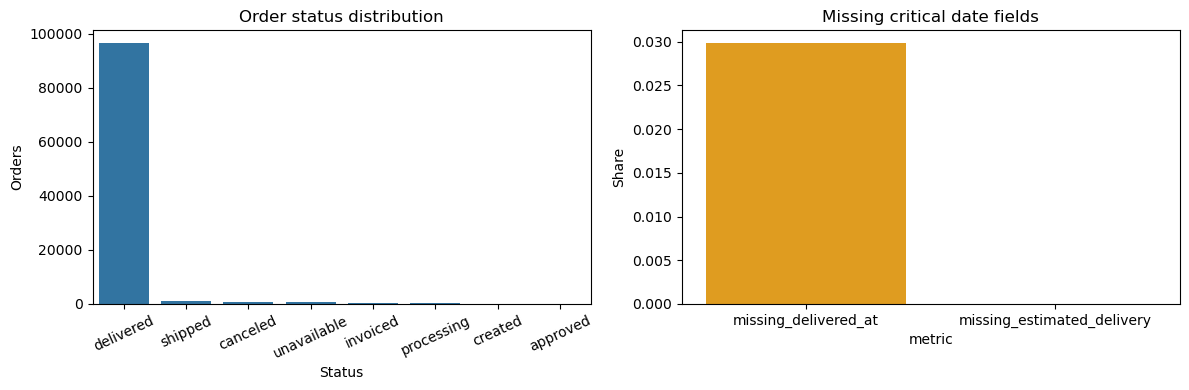

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

total_orders = quality_df["total_orders"].iloc[0]
missing_delivered = quality_df["missing_delivered_at"].iloc[0]
missing_estimated = quality_df["missing_estimated_delivery"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=status_df, x="order_status", y="orders", ax=axes[0])
axes[0].set_title("Order status distribution")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Orders")
axes[0].tick_params(axis="x", rotation=25)

missing_plot = pd.DataFrame(
    {
        "metric": ["missing_delivered_at", "missing_estimated_delivery"],
        "share_pct": [missing_delivered/total_orders, missing_estimated/total_orders,],
    }
)
sns.barplot(data=missing_plot, x="metric", y="share_pct", color="orange", ax=axes[1])
axes[1].set_title("Missing critical date fields")
axes[1].set_ylabel("Share")

plt.tight_layout()
plt.savefig("artifacts/plot_01.png")
plt.show()


## 2) Данные по заказам и базовые метрики

Собираю `v_order_facts` на уровне заказа (деньги, сроки, отзывы и география).
AOV, GMV, доля просрочек.

In [4]:
my_con.execute(
    """
    CREATE OR REPLACE VIEW v_order_facts AS
    WITH items AS (
        SELECT
            order_id,
            SUM(price + freight_value) AS gmv_items,
            COUNT(*) AS n_lines
        FROM order_items
        GROUP BY order_id
    ),
    pays AS (
        SELECT
            order_id,
            SUM(payment_value) AS gmv_payments,
            MAX(payment_installments) AS max_installments
        FROM payments
        GROUP BY order_id
    ),
    rev AS (
        SELECT
            order_id,
            AVG(review_score) AS review_score,
            CASE WHEN AVG(review_score) <= 2 THEN 1 ELSE 0 END AS bad_review
        FROM reviews
        GROUP BY order_id
    ),
    orders_typed AS (
        SELECT
            order_id,
            customer_id,
            order_status,
            CAST(order_purchase_timestamp AS TIMESTAMP) AS purchased_at,
            CAST(order_delivered_customer_date AS TIMESTAMP) AS delivered_at,
            CAST(order_estimated_delivery_date AS TIMESTAMP) AS estimated_delivery
        FROM orders
        WHERE order_status = 'delivered'
          AND order_delivered_customer_date IS NOT NULL
          AND order_estimated_delivery_date IS NOT NULL
    )
    SELECT
        o.order_id,
        o.customer_id,
        c.customer_state,
        o.purchased_at,
        o.delivered_at,
        o.estimated_delivery,
        i.gmv_items,
        p.gmv_payments,
        i.n_lines,
        p.max_installments,
        r.review_score,
        r.bad_review,
        date_diff('day', o.purchased_at, o.delivered_at) AS delivery_days,
        CASE WHEN o.delivered_at > o.estimated_delivery THEN 1 ELSE 0 END AS is_late
    FROM orders_typed o
    JOIN customers c ON c.customer_id = o.customer_id
    LEFT JOIN items i ON i.order_id = o.order_id
    LEFT JOIN pays p ON p.order_id = o.order_id
    LEFT JOIN rev r ON r.order_id = o.order_id
    """
)

facts = my_con.execute("SELECT * FROM v_order_facts").df()
facts.head()


,order_id,customer_id,customer_state,purchased_at,delivered_at,estimated_delivery,gmv_items,gmv_payments,n_lines,max_installments,review_score,bad_review,delivery_days,is_late
0,000aed2e25dbad2f9ddb70584c5a2ded,fff5169e583fd07fac9fec88962f189d,SP,2018-05-11 20:33:38,2018-05-18 16:46:31,2018-05-22,152.77,152.77,1,1,1.0,1,7,0
1,0039500db36d50d7d0bfaf23723550f3,90bd9911aed064dfc625750fbd83ebca,AL,2018-07-06 10:37:32,2018-07-21 00:08:29,2018-08-03,203.23,203.23,1,2,5.0,0,15,0
2,0071ee2429bc1efdc43aa3e073a5290e,081a2d41949e652a50988fd39febb4a8,SP,2018-01-22 11:08:15,2018-01-31 23:58:36,2018-02-15,192.44,192.44,1,1,4.0,0,9,0
3,00789ce015e7e5791c7914f32bb4fad4,342c4258969c528c3469db9acaf6b0ad,RJ,2017-06-28 23:31:33,2017-07-17 18:35:36,2017-07-20,168.83,190.81,1,10,5.0,0,19,0
4,007ec946d4f798caf2b43c9d44c56421,3ace63287bc8b41172016c06a5093808,RS,2017-11-24 13:05:15,2017-12-06 22:38:40,2017-12-26,43.00,43.00,1,1,5.0,0,12,0


,metric,value
0,"Orders (delivered, known dates)",9.647000e+04
1,GMV items sum,1.541839e+07
2,GMV payments sum,1.542108e+07
3,AOV items,1.598258e+02
4,"Late delivery share, %",8.112367e+00
5,Average review score,4.156158e+00


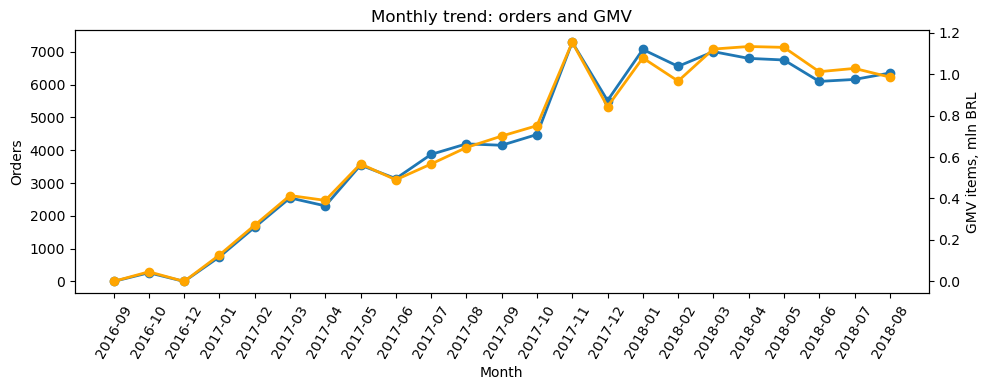

In [5]:
summary = pd.DataFrame(
    {
        "metric": [
            "Orders (delivered, known dates)",
            "GMV items sum",
            "GMV payments sum",
            "AOV items",
            "Late delivery share, %",
            "Average review score",
        ],
        "value": [
            facts.shape[0],
            facts["gmv_items"].sum(),
            facts["gmv_payments"].sum(),
            facts["gmv_items"].mean(),
            facts["is_late"].mean() * 100,
            facts["review_score"].mean(skipna=True),
        ],
    }
)
display(summary)

monthly = my_con.execute(
    """
    SELECT
        strftime(purchased_at, '%Y-%m') AS ym,
        COUNT(*) AS orders,
        SUM(gmv_items) AS gmv_items
    FROM v_order_facts
    GROUP BY ym
    ORDER BY ym
    """
).df()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(monthly["ym"], monthly["orders"], marker="o", lw=2)
ax1.set_ylabel("Orders")
ax1.set_xlabel("Month")
ax1.tick_params(axis="x", rotation=60)

ax2 = ax1.twinx()
ax2.plot(monthly["ym"], monthly["gmv_items"]/1e6, color="orange", marker="o", lw=2)
ax2.set_ylabel("GMV items, mln BRL")

ax1.set_title("Monthly trend: orders and GMV")
plt.tight_layout()
plt.savefig("artifacts/plot_02.png")
plt.show()


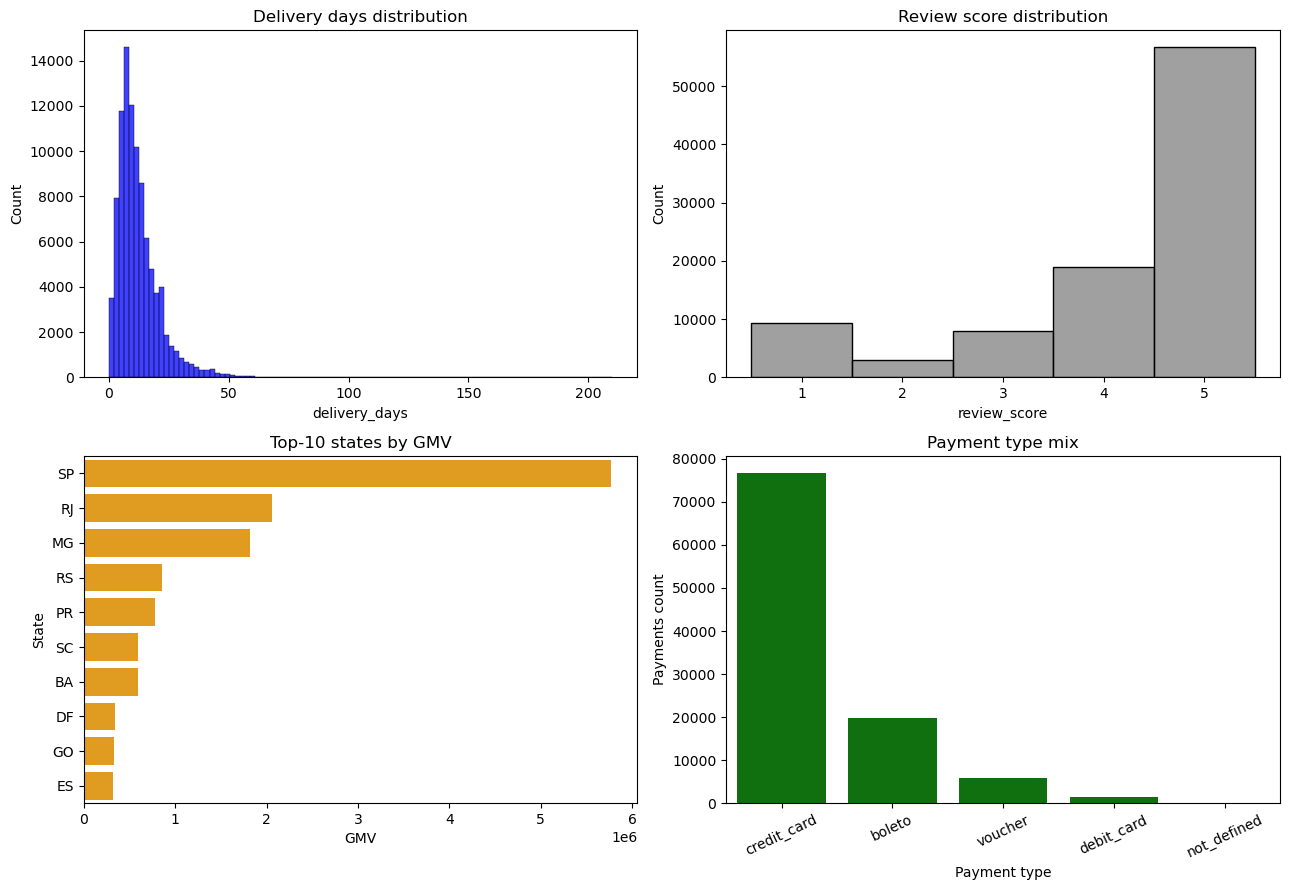

In [6]:
state_gmv = my_con.execute(
    """
    SELECT customer_state, SUM(gmv_items) AS gmv_items
    FROM v_order_facts
    GROUP BY customer_state
    ORDER BY gmv_items DESC
    LIMIT 10
    """
).df()

payment_data = my_con.execute(
    """
    SELECT payment_type, COUNT(*) AS payments
    FROM payments
    GROUP BY payment_type
    ORDER BY payments DESC
    """
).df()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(data=facts, color='blue', x="delivery_days", bins=100, ax=axes[0, 0])
axes[0, 0].set_title("Delivery days distribution")

sns.histplot(data=facts.dropna(subset=["review_score"]), x="review_score", discrete=True, color="grey", ax=axes[0, 1])
axes[0, 1].set_title("Review score distribution")

sns.barplot(data=state_gmv, y="customer_state", x="gmv_items", color="orange", ax=axes[1, 0])
axes[1, 0].set_title("Top-10 states by GMV")
axes[1, 0].set_xlabel("GMV")
axes[1, 0].set_ylabel("State")

sns.barplot(data=payment_data, x="payment_type", y="payments", color="green", ax=axes[1, 1])
axes[1, 1].set_title("Payment type mix")
axes[1, 1].set_xlabel("Payment type")
axes[1, 1].set_ylabel("Payments count")
axes[1, 1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("artifacts/plot_03.png")
plt.show()


## 3) Данные по заказам: отзывы, задержки, продавцы

Собираем `v_case_order_base` со всеми признаками, которые нужны для проверки гипотез.
Метрики: `bad_review`, `is_late`, `delay_days`.

In [7]:
my_con.execute(
    """
    CREATE OR REPLACE VIEW v_case_order_base AS
    WITH seller_order_value AS (
        SELECT order_id, seller_id, SUM(price + freight_value) AS seller_value
        FROM order_items
        GROUP BY order_id, seller_id
    ),
    primary_seller AS (
        SELECT
            order_id,
            seller_id,
            ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY seller_value DESC, seller_id) AS rn
        FROM seller_order_value
    )
    SELECT
        f.order_id,
        f.purchased_at,
        f.estimated_delivery,
        f.delivered_at,
        date_diff('day', f.estimated_delivery, f.delivered_at) AS delay_days,
        f.review_score,
        f.bad_review,
        f.is_late,
        ps.seller_id AS primary_seller_id
    FROM v_order_facts f
    LEFT JOIN primary_seller ps ON ps.order_id = f.order_id AND ps.rn = 1
    WHERE f.review_score IS NOT NULL
      AND f.bad_review IS NOT NULL
    """
)

case_preview = my_con.execute(
    """
    SELECT order_id, delay_days, review_score, bad_review, is_late, primary_seller_id
    FROM v_case_order_base
    LIMIT 5
    """
).df()
display(case_preview)

kpi_case = my_con.execute(
    """
    SELECT
        COUNT(*) AS orders,
        AVG(bad_review) AS bad_review_rate,
        AVG(is_late) AS late_rate,
        AVG(delay_days) AS avg_delay_days,
        MEDIAN(delay_days) AS median_delay_days
    FROM v_case_order_base
    """
).df()
display(kpi_case)

delay_bucket = my_con.execute(
    """
    SELECT
        CASE
            WHEN delay_days <= -3 THEN 'Early (>=3 days)'
            WHEN delay_days BETWEEN -2 AND 0 THEN 'On time / slightly early'
            WHEN delay_days BETWEEN 1 AND 3 THEN 'Late 1-3 days'
            ELSE 'Late 4+ days'
        END AS delay_bucket,
        COUNT(*) AS orders,
        AVG(bad_review) AS bad_review_rate,
        AVG(is_late) AS late_rate,
        AVG(delay_days) AS avg_delay_days
    FROM v_case_order_base
    GROUP BY delay_bucket
    ORDER BY avg_delay_days
    """
).df()
delay_bucket


,order_id,delay_days,review_score,bad_review,is_late,primary_seller_id
0,000e63d38ae8c00bbcb5a30573b99628,-9,3.0,0,0,1c129092bf23f28a5930387c980c0dfc
1,000f25f4d72195062c040b12dce9a18a,-20,4.0,0,0,7c67e1448b00f6e969d365cea6b010ab
2,00119ff934e539cf26f92b9ef0cdfed8,-15,5.0,0,0,c864036feaab8c1659f65ea4faebe1da
3,002b430ff89b3a24c31a1170acbbedea,-13,5.0,0,0,7a67c85e85bb2ce8582c35f2203ad736
4,00335f75ea6a4455b524a8dd177067f5,-25,5.0,0,0,70c27847eca8195c983ed7e798c56743


,orders,bad_review_rate,late_rate,avg_delay_days,median_delay_days
0,95824,0.127692,0.079949,-11.91307,-12.0


,delay_bucket,orders,bad_review_rate,late_rate,avg_delay_days
0,Early (>=3 days),85173,0.091120,0.000000,-14.137649
1,On time / slightly early,4270,0.116159,0.299766,-1.060890
2,Late 1-3 days,1852,0.321814,1.000000,1.825054
3,Late 4+ days,4529,0.746964,1.000000,14.073305


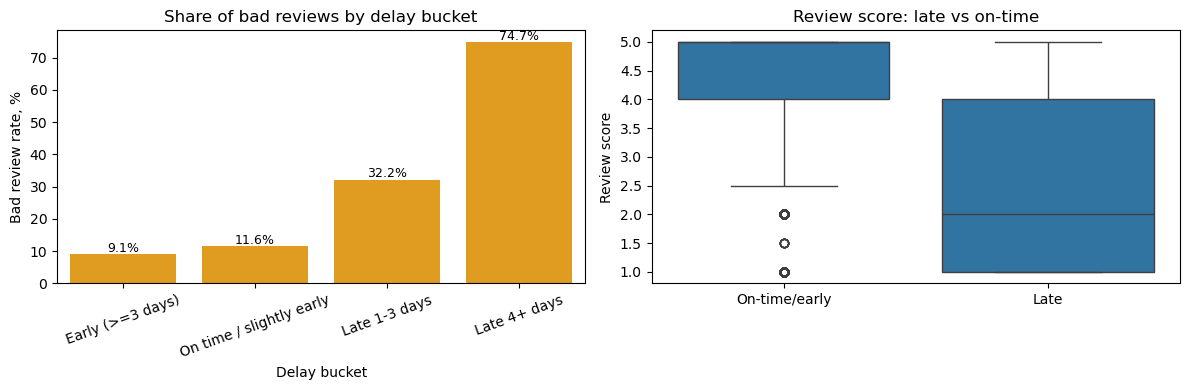

In [8]:
plot_df = delay_bucket.copy()
plot_df["bad_review_rate_pct"] = plot_df["bad_review_rate"]*100

review_by_late = my_con.execute(
    """
    SELECT
        CASE WHEN is_late = 1 THEN 'Late' ELSE 'On-time/early' END AS delivery_group,
        review_score
    FROM v_case_order_base
    """
).df()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=plot_df, x="delay_bucket", y="bad_review_rate_pct", color="orange", ax=axes[0])
axes[0].set_xlabel("Delay bucket")
axes[0].set_ylabel("Bad review rate, %")
axes[0].set_title("Share of bad reviews by delay bucket")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(plot_df["bad_review_rate_pct"]):
    axes[0].text(i, v + 0.7, f"{v:.1f}%", ha="center", fontsize=9)

sns.boxplot(data=review_by_late, x="delivery_group", y="review_score", ax=axes[1])
axes[1].set_title("Review score: late vs on-time")
axes[1].set_xlabel("")
axes[1].set_ylabel("Review score")

plt.tight_layout()
plt.savefig("artifacts/plot_04.png")
plt.show()


## 4) Анализ продавцов

Выделим продавцов, у которых одновременно высокие `late_rate` и `bad_review_rate`. В случае чего, будем их менять.

Sellers with >=50 orders: 413
Risk sellers (above median benchmark on both metrics): 132


,seller_id,orders,bad_review_rate,late_rate,avg_delay_days
0,1ca7077d890b907f89be8c954a02686a,107,0.598131,0.214953,-6.728972
1,2eb70248d66e0e3ef83659f71b244378,183,0.475410,0.136612,-10.032787
2,972d0f9cf61b499a4812cf0bfa3ad3c4,78,0.410256,0.115385,-9.500000
3,a49928bcdf77c55c6d6e05e09a9b4ca5,96,0.406250,0.260417,-4.447917
4,54965bbe3e4f07ae045b90b0b8541f52,69,0.405797,0.289855,-3.739130
...,...,...,...,...,...
197,5d0363b33554b373851fc1622e4d5f3c,93,0.118280,0.086022,-8.967742
198,624f4ece8da4aafb77699233d480f8ef,51,0.117647,0.078431,-10.529412
199,e24fc9fcd865784fb25705606fe3dfe7,51,0.117647,0.078431,-13.784314
200,004c9cd9d87a3c30c522c48c4fc07416,154,0.116883,0.084416,-11.733766


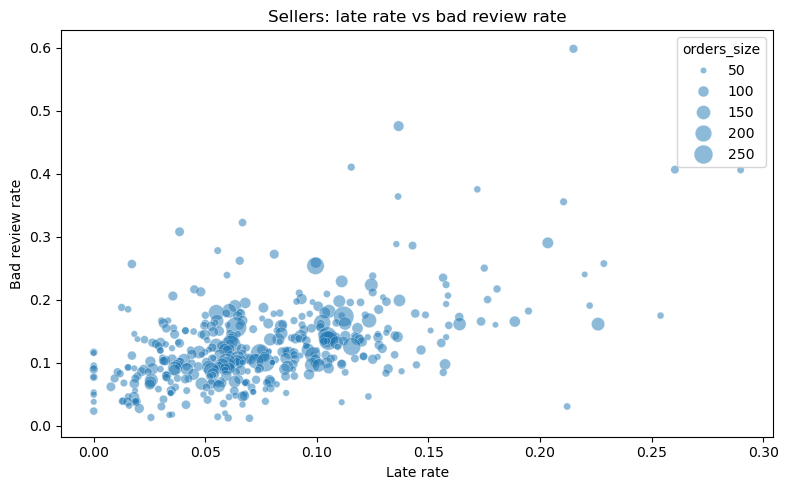

,total_case_orders,total_late_bad_orders,late_bad_orders_from_risk_sellers,risk_share_of_late_bad_pct
0,95824,4136,1733,0.419004


In [9]:
import numpy as np

seller_perf = my_con.execute(
    """
    WITH seller_stats AS (
        SELECT
            primary_seller_id AS seller_id,
            COUNT(*) AS orders,
            AVG(bad_review) AS bad_review_rate,
            AVG(is_late) AS late_rate,
            AVG(delay_days) AS avg_delay_days
        FROM v_case_order_base
        WHERE primary_seller_id IS NOT NULL
        GROUP BY seller_id
    )
    SELECT *
    FROM seller_stats
    WHERE orders >= 50
    ORDER BY bad_review_rate DESC, late_rate DESC
    """
).df()

bench_bad = seller_perf["bad_review_rate"].median()
bench_late = seller_perf["late_rate"].median()

is_risk = (seller_perf["bad_review_rate"] > bench_bad) & (seller_perf["late_rate"] > bench_late)
risk_sellers = seller_perf[is_risk].sort_values(["bad_review_rate", "late_rate"], ascending=False)

print("Sellers with >=50 orders:", len(seller_perf))
print("Risk sellers (above median benchmark on both metrics):", len(risk_sellers))
display(risk_sellers)

viz_df = seller_perf.assign(orders_size=np.sqrt(seller_perf["orders"]) * 7)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=viz_df, x="late_rate", y="bad_review_rate", size="orders_size", sizes=(20, 220), alpha=0.5, ax=ax)
ax.set_xlabel("Late rate")
ax.set_ylabel("Bad review rate")
ax.set_title("Sellers: late rate vs bad review rate")

plt.tight_layout()
plt.savefig("artifacts/plot_05.png")
plt.show()

risk_seller_ids = risk_sellers["seller_id"].tolist()

case_orders = my_con.execute(
    """
    SELECT primary_seller_id, is_late, bad_review
    FROM v_case_order_base
    """
).df()

total_case_orders = len(case_orders)
total_late_bad = ((case_orders["is_late"] == 1) & (case_orders["bad_review"] == 1)).sum()
late_bad_from_risk = ((case_orders["is_late"] == 1) & (case_orders["bad_review"] == 1) & (case_orders["primary_seller_id"].isin(risk_seller_ids))).sum()

risk_impact = pd.DataFrame(
    {
        "total_case_orders": [total_case_orders],
        "total_late_bad_orders": [total_late_bad],
        "late_bad_orders_from_risk_sellers": [late_bad_from_risk],
    }
)
risk_impact["risk_share_of_late_bad_pct"] = late_bad_from_risk/total_late_bad

display(risk_impact)


## 4.1) Бимодальность delay_days у risk-продавцов

У ряда risk-продавцов `avg_delay_days` отрицательный (доставляют в среднем раньше обещанного), хотя `bad_review_rate` высокий и `late_rate` ненулевой. Это говорит о том, что среднее маскирует двугорбое распределение: большинство заказов приходит сильно заранее, а меньшинство — с серьёзным опозданием, и именно они получают плохие оценки.

Проверим это, сравнив распределение `delay_days` для заказов risk-продавцов с плохими и хорошими отзывами.

,count,mean,median,std
Good review,21593,-11.716945,-12.0,8.391755
Bad review,4489,-3.395634,-6.0,14.561317


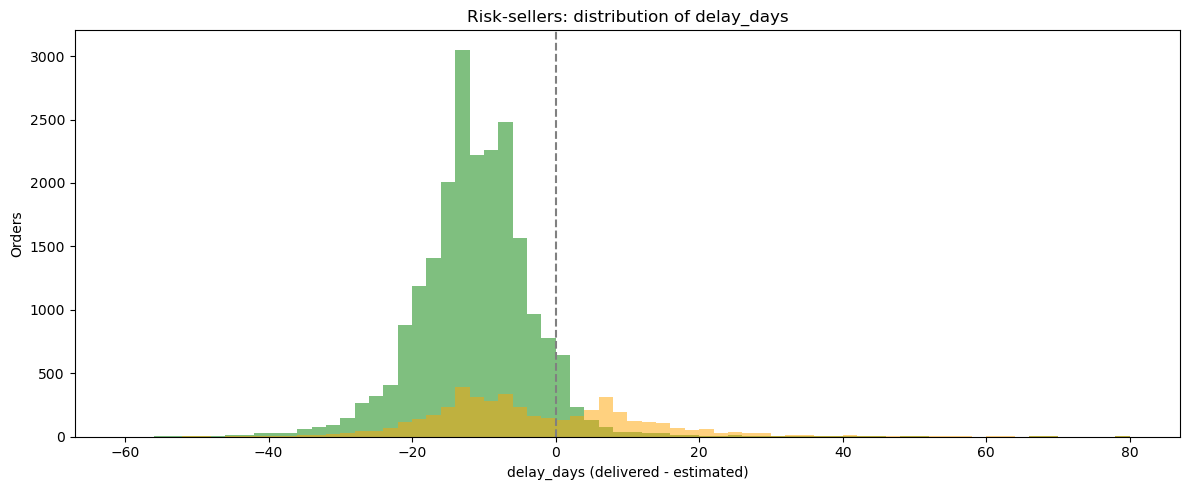

In [10]:
risk_seller_ids = risk_sellers["seller_id"].tolist()

all_delays = my_con.execute(
    """
    SELECT primary_seller_id, bad_review, delay_days
    FROM v_case_order_base
    WHERE delay_days IS NOT NULL
    """
).df()

bimodal = all_delays[all_delays["primary_seller_id"].isin(risk_seller_ids)]

fig, ax = plt.subplots(figsize=(12, 5))

bins_for_hist = np.linspace(-60, 80, 71)

good_mask = bimodal["bad_review"] == 0
bad_mask = bimodal["bad_review"] == 1
good_delays = bimodal.loc[good_mask, "delay_days"]
bad_delays = bimodal.loc[bad_mask, "delay_days"]

ax.hist(good_delays, bins=bins_for_hist, alpha=0.5, label=f"Good review (3-5) (n={len(good_delays)})", color="green")
ax.hist(bad_delays, bins=bins_for_hist, alpha=0.5, label=f"Bad review (1-2) (n={len(bad_delays)})", color="orange")
ax.axvline(color="gray", linestyle="--")
ax.set_xlabel("delay_days (delivered - estimated)")
ax.set_ylabel("Orders")
ax.set_title("Risk-sellers: distribution of delay_days")

stats = bimodal.groupby("bad_review")["delay_days"].agg(["count", "mean", "median", "std"])
stats.index = ["Good review", "Bad review"]
display(stats)

plt.tight_layout()
plt.savefig("artifacts/plot_08_bimodality.png")
plt.show()


### Вывод по бимодальности

У risk-продавцов распределение `delay_days` действительно двугорбое:
- Основная масса заказов приходит раньше срока (отрицательные `delay_days`) — отсюда отрицательное среднее.
- Хвост из опаздывающих заказов (положительные `delay_days`) почти целиком состоит из заказов с плохими отзывами.

Это значит, что для risk-продавцов проблема не в системной просрочке, а в нестабильности логистики: часть заказов уходит сильно заранее, но когда происходит сбой — клиент получает заказ с большим опозданием и ставит 1-2 звезды. Среднее арифметическое эту картину скрывает.
Для таких продавцов эффективнее работать над сокращением разброса и предотвращением выбросов в сроках доставки.

## 5) Проверка гипотез (матстат)

Дальше проверяю, насколько эффект устойчив статистически:
- late-факт и плохой отзыв (хи-квадрат);
- длительность доставки и оценка (Spearman);
- быстрые vs долгие доставки (Mann-Whitney).

плюс смотрим квартили задержки, чтобы понять, как растет риск по мере ухудшения сроков.

## 5.1) Хи-квадрат и Odds Ratio

Odds Ratio:
- шанс плохого отзыва при late = 1.173
- шанс плохого отзыва при on-time = 0.101
- Odds Ratio = 1.173 / 0.101 ≈ 11.6
Шансы получить 1–2 звезды при просрочке в 11.6 раз выше, чем при доставке вовремя.

## 5.2) Spearman ρ = −0.235

По Cohen: 0.1 — слабая, 0.3 — средняя, 0.5 — сильная корреляция. ρ = −0.235 — слабая отрицательная связь между `delivery_days` и `review_score` на уровне отдельного заказа. Это объяснимо: на индивидуальную оценку влияет множество факторов помимо скорости доставки (качество товара, соответствие описанию, упаковка). Именно поэтому анализ на агрегированном уровне (по бакетам и продавцам) даёт более выраженную картину.

### 5.3) Mann-Whitney

Медианы: 5.0 (≤7 дней) vs 4.0 (>14 дней) — сдвиг на 1 балл по 5-балльной шкале. При p = 0 эффект устойчив.

bad_review,0,1
is_late,,
0,80063,8100
1,3525,4136


chi2 = 12696.532367511776, p-value = 0.0, dof = 1
bad_review_rate late orders: 0.5398773006134969
bad_review_rate on-time/early orders: 0.09187527647652644
Spearman rho = -0.23510770337274234, p-value = 0.0
Mann-Whitney p-value (<=7 vs >14 days): 0.0
Median review (<=7 days): 5.0 | (>14 days): 4.0


,delay_quartile,orders,bad_review_rate
0,1,23956,0.093004
1,2,23956,0.085490
2,3,23956,0.089623
3,4,23956,0.242653


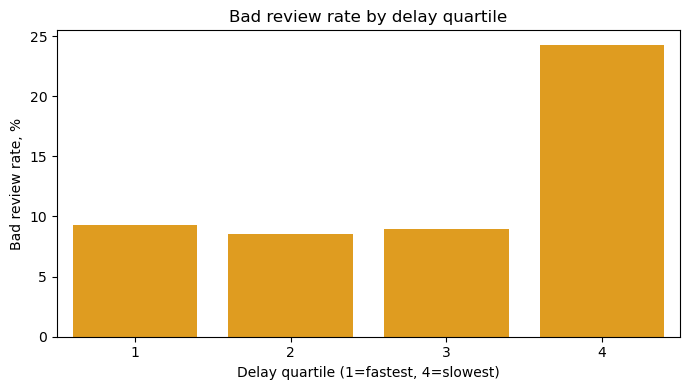

In [11]:
from scipy import stats
from scipy.stats import chi2_contingency

contingency_data = my_con.execute(
    """
    SELECT is_late, bad_review, COUNT(*) AS n
    FROM v_case_order_base
    GROUP BY is_late, bad_review
    ORDER BY is_late, bad_review
    """
).df()

pivot = contingency_data.pivot_table(index="is_late", columns="bad_review", values="n", fill_value=0).astype(int)
chi2, p_value, dof, expected = chi2_contingency(pivot)

display(pivot)
print(f"chi2 = {chi2}, p-value = {p_value}, dof = {dof}")

rates = my_con.execute(
    """
    SELECT is_late, AVG(bad_review) AS bad_review_rate
    FROM v_case_order_base
    GROUP BY is_late
    ORDER BY is_late DESC
    """
).df()

late_bad = rates.loc[rates["is_late"] == 1, "bad_review_rate"].iloc[0]
ontime_bad = rates.loc[rates["is_late"] == 0, "bad_review_rate"].iloc[0]
print(f"bad_review_rate late orders: {late_bad}")
print(f"bad_review_rate on-time/early orders: {ontime_bad}")

review_delivery = my_con.execute(
    "SELECT delivery_days, review_score FROM v_order_facts WHERE review_score IS NOT NULL"
).df()

rho, p_sp = stats.spearmanr(review_delivery["delivery_days"], review_delivery["review_score"])
print(f"Spearman rho = {rho}, p-value = {p_sp}")

fast = review_delivery.loc[review_delivery["delivery_days"] <= 7, "review_score"]
slow = review_delivery.loc[review_delivery["delivery_days"] > 14, "review_score"]
u_stat, p_mw = stats.mannwhitneyu(fast, slow, alternative="two-sided")
print(f"Mann-Whitney p-value (<=7 vs >14 days): {p_mw}")
print(f"Median review (<=7 days): {fast.median()} | (>14 days): {slow.median()}")

quantile_effect = my_con.execute(
    """
    WITH q AS (
        SELECT
            delay_days,
            bad_review,
            NTILE(4) OVER (ORDER BY delay_days) AS delay_quartile
        FROM v_case_order_base
    )
    SELECT delay_quartile, COUNT(*) AS orders, AVG(bad_review) AS bad_review_rate
    FROM q
    GROUP BY delay_quartile
    ORDER BY delay_quartile
    """
).df()

display(quantile_effect)

quantile_plot = quantile_effect.copy()
quantile_plot["bad_review_rate_pct"] = quantile_plot["bad_review_rate"] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=quantile_plot, x="delay_quartile", y="bad_review_rate_pct", color="orange", ax=ax)
ax.set_title("Bad review rate by delay quartile")
ax.set_xlabel("Delay quartile (1=fastest, 4=slowest)")
ax.set_ylabel("Bad review rate, %")
plt.tight_layout()

plt.savefig("artifacts/plot_06.png")
plt.show()


## 6) Выводы

- Плохие отзывы при просрочке: **53.99%**.
- Плохие отзывы при доставке вовремя/раньше: **9.19%**.
- Разница почти в **5.9 раза**.
- По продавцам (`orders >= 50`): **413** продавцов, из них **114** в risk-группе.
- Статтесты подтверждают, что эффект устойчив: хи квадрат, Spearman и Mann-Whitney значимы.

Гипотезы `H1`, `H2`, `H3` подтвердились. Логистика и соблюдение качества обслуживания заметно связаны с оценкой клиента, а риск концентрируется в части продавцов (будем их называть risk-продавцы).

### Что делать дальше
1. Вести еженедельный мониторинг `risk_sellers`.
2. Для top-risk продавцов запустить короткий операционный план: контроль отгрузки, SLA, коммуникация с логистикой.
3. Через 4-6 недель пересчитать тот же срез и проверить динамику `late+bad`.

## 7) Что еще проверить

- `H4`: в регионах с более высоким `late_rate` обычно выше `bad_review_rate`.
- `H5`: у заказов с большим числом платежей (`installments`) риск негатива выше.

,installments_group,orders,late_rate,bad_review_rate
0,1-3,68531,0.078738,0.121930
1,4-7,17177,0.081330,0.134715
2,8+,10116,0.085805,0.154804


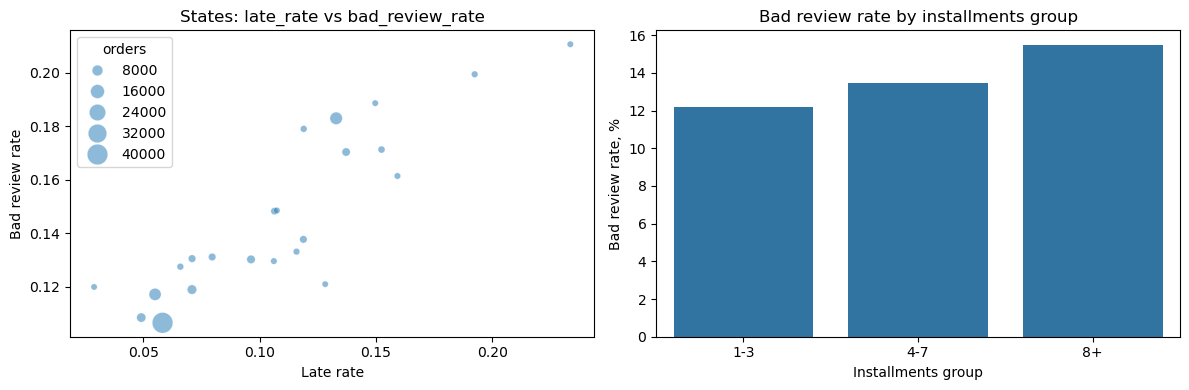

In [12]:
state_check = my_con.execute(
    """
    WITH st AS (
        SELECT
            customer_state,
            AVG(is_late) AS late_rate,
            AVG(bad_review) AS bad_review_rate,
            COUNT(*) AS orders
        FROM v_order_facts
        WHERE review_score IS NOT NULL
        GROUP BY customer_state
        HAVING COUNT(*) >= 200
    )
    SELECT *
    FROM st
    ORDER BY orders DESC
    """
).df()

installment_check = my_con.execute(
    """
    SELECT
        CASE
            WHEN max_installments >= 8 THEN '8+'
            WHEN max_installments BETWEEN 4 AND 7 THEN '4-7'
            ELSE '1-3'
        END AS installments_group,
        COUNT(*) AS orders,
        AVG(is_late) AS late_rate,
        AVG(bad_review) AS bad_review_rate
    FROM v_order_facts
    WHERE review_score IS NOT NULL
    GROUP BY installments_group
    ORDER BY installments_group
    """
).df()

display(installment_check)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=state_check, x="late_rate", y="bad_review_rate", size="orders", sizes=(20, 220), alpha=0.5, ax=axes[0])
axes[0].set_title("States: late_rate vs bad_review_rate")
axes[0].set_xlabel("Late rate")
axes[0].set_ylabel("Bad review rate")

plot_inst = installment_check.copy()
plot_inst["bad_review_rate_pct"] = plot_inst["bad_review_rate"] * 100
sns.barplot(data=plot_inst, x="installments_group", y="bad_review_rate_pct", ax=axes[1])
axes[1].set_title("Bad review rate by installments group")
axes[1].set_xlabel("Installments group")
axes[1].set_ylabel("Bad review rate, %")

plt.tight_layout()
plt.savefig("artifacts/plot_07.png")
plt.show()


## 8) Дизайн эксперимента для проверки причинности

A/B-тест на risk-продавцах:
- Выборка: только risk-продавцы (114 шт.).
  - Стратифицированная рандомизация.
  - test-группа: операционные меры (SLA-напоминания, быстрые эскалации, уведомления клиенту);
  - control-группа: без изменений;
- главная метрика: доля заказов опаздавших заказов с низкой оценкой (`is_late = 1` и `bad_review = 1`);
- срок: 6–8 недель.